# Control Flow
**Topic:** Python Fundamentals

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


---
## What you'll explore

By the end of this demo you will be able to:

- **Trace** the path Python takes through an `if`/`elif`/`else` chain for a given input
- **Explain** how `for` and `while` loops iterate over sequences and conditions
- **Interpret** how `break`, `continue`, and early `return` change a loop's behavior

---
## How we got here

In *01: Data Types, Variables & Operators* we learned how Python represents values and which operations are valid for each type. Control flow is what happens next: once you have values, Python needs rules for deciding what to do with them. Every conditional check in a data pipeline and every loop over a DataFrame row is built from the constructs in this notebook.

---
## Why this matters for data science

Data quality checks are pure control flow. When you write a validation function that flags rows where `age < 0` or `salary > 500_000`, you are writing an `if`/`elif`/`else` chain. The logic inside `pd.cut()`, `np.where()`, and sklearn's `OneHotEncoder` all reduce to conditional branches over arrays. Understanding control flow lets you write and debug those checks from scratch when a library function does not quite fit your needs.

---
## Try it yourself

In [4]:
# ▶ Run this cell and observe the output.
# Then try changing the values and running again.

scores = [45, 72, 88, 61, 95, 30, 55]

for score in scores:
    if score >= 90:
        grade = 'A'
    elif score >= 80:
        grade = 'B'
    elif score >= 70:
        grade = 'C'
    elif score >= 60:
        grade = 'D'
    else:
        grade = 'F'
    print(f'Score {score}: {grade}')

Score 45: F
Score 72: C
Score 88: B
Score 61: D
Score 95: A
Score 30: F
Score 55: F


In [5]:
# ✏️ Your turn — modify this code:
# 1. Add an 'A+' grade for scores above 97
# 2. Change the thresholds so that 75+ is a B instead of 80+
# 3. What happens if score is exactly 80? Which branch runs?

def classify_score(score):
    if score >= 90:
        return 'A'
    elif score >= 80:
        return 'B'
    elif score >= 70:
        return 'C'
    elif score >= 60:
        return 'D'
    else:
        return 'F'

for s in [59, 60, 79, 80, 89, 90, 100]:
    print(f'{s} → {classify_score(s)}')

59 → F
60 → D
79 → C
80 → B
89 → B
90 → A
100 → A


In [6]:
# 🎯 Challenge:
# Write an if/elif/else block that categorizes a number as:
#   negative, zero, small (1–10), medium (11–100), or large (>100)
# Test it with at least five different numbers.
# Hint: start with the number -5, then try 0, 7, 50, and 200

# Your code here:

---
## What's happening?

Control flow tells Python which lines of code to execute and how many times to execute them. The three main tools are conditionals, for-loops, and while-loops.

| Construct | Purpose | Typical data science use |
|-----------|---------|-------------------------|
| `if` / `elif` / `else` | Execute a block when a condition is true | Data validation, label encoding, branching logic |
| `for` loop | Iterate over every item in a sequence | Processing columns, reading batches of files |
| `while` loop | Repeat until a condition becomes false | Training loops, retry logic, streaming data |
| `break` / `continue` | Exit or skip iterations early | Stop when a target is found; skip malformed rows |

```python
# A simple data quality check
def classify_age(age):
    if age < 0:
        return "invalid"
    elif age < 18:
        return "minor"
    elif age < 65:
        return "adult"
    else:
        return "senior"
```

### Python evaluates conditions top to bottom and stops at the first match

In an `if`/`elif`/`else` chain, only the first truthy branch runs. If `age = 30`, Python checks `age < 0` (False), then `age < 18` (False), then `age < 65` (True) and stops. The `else` block never executes.

Go back to the widget and verify this: set value to 30 and watch exactly which branch lights up.

---
## Real-world example: Data validation on a patient intake form

A hospital's data pipeline receives patient records and needs to flag rows before they reach analysis. Each field has validation rules implemented as conditional checks. The chart below shows how 200 simulated patient records are classified by a multi-condition validator.

Notice:

- **Notice:** The majority of records pass all checks, but a meaningful fraction fail at least one condition, which is realistic for self-reported survey data
- **Notice:** Age and BMI violations are the most common because those fields have clear numeric bounds, while text fields like `name` fail less frequently
- **Notice:** Each bar represents a separate `if` check; a single record can trigger multiple flags, which is why the total of flagged counts can exceed the number of flagged records

> **Discussion question:** The validator currently checks each field independently. What would change if instead it used `if`/`elif`/`else` so that a record failing the age check skips all remaining checks? Would that be better or worse for a data quality report?

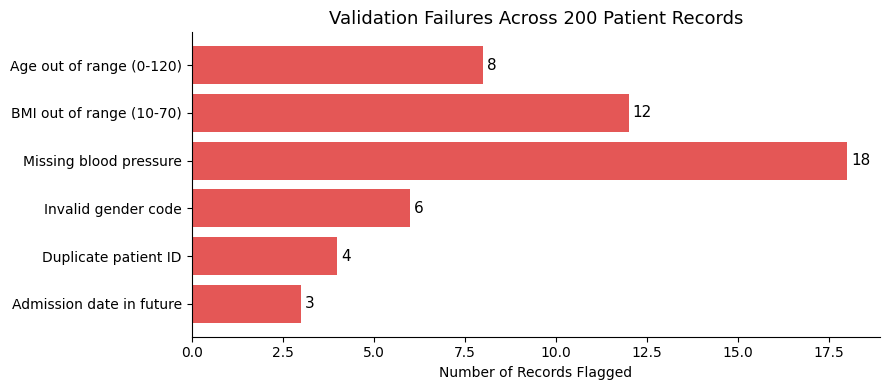

In [7]:
import numpy as np
np.random.seed(42)

# ── Simulated patient record validation results ──────────────────────────────
n       = 200
checks  = {
    "Age out of range (0-120)":    int(n * 0.04),
    "BMI out of range (10-70)":    int(n * 0.06),
    "Missing blood pressure":      int(n * 0.09),
    "Invalid gender code":         int(n * 0.03),
    "Duplicate patient ID":        int(n * 0.02),
    "Admission date in future":    int(n * 0.015),
}
labels = list(checks.keys())
counts = list(checks.values())

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(labels[::-1], counts[::-1], color="#E45756")
for bar, count in zip(bars, counts[::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            str(count), va="center", fontsize=11)
ax.set_title(f"Validation Failures Across {n} Patient Records", fontsize=13)
ax.set_xlabel("Number of Records Flagged")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


### Common control flow patterns in data science code

| Pattern | Code sketch | Where you see it |
|---------|------------|-----------------|
| Value bucketing | `if x < q1 ... elif x < q3 ... else` | `pd.cut()`, outlier labeling |
| Skip-bad-rows loop | `for row in data: if invalid(row): continue` | Data cleaning loops |
| Early exit | `for item in items: if found(item): break` | Searching for first match |
| Accumulator pattern | `total = 0; for x in values: total += x` | Manual aggregations, custom metrics |
| Conditional list build | `result = []; for x in data: if x > 0: result.append(x)` | Pre-comprehension filtering |

---
## Key takeaway

> **Control flow determines which lines Python executes and how many times; every data validation check, cleaning loop, and branching pipeline is built from the same three constructs: if, for, and while.**

---
*Next up: Functions — how to package control flow and logic into reusable, testable units*